🔬 SciPy Tutorial &nbsp;·&nbsp; *Bài 10/11*

[« SciPy Matlab Arrays](009_scipy_matlab_arrays.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../../README.md) &nbsp;•&nbsp; [SciPy Statistical Significance Tests »](011_scipy_significance_tests.ipynb)

# SciPy Interpolation

> 📖 **Học song song trên W3Schools:** [scipy_interpolation.php](https://www.w3schools.com/python/scipy/scipy_interpolation.php)
>
> 🎯 **Trong bài này:** What is Interpolation? · How to Implement it in SciPy? · 1D Interpolation · Spline Interpolation · Interpolation with Radial Basis Function · ➕ Mở rộng: Trực quan hoá nội suy

## What is Interpolation? — Nội suy là gì?

**Nội suy** là phương pháp tạo ra các điểm **nằm giữa** các điểm đã cho.

Ví dụ: với các điểm 1 và 2, ta có thể nội suy ra các điểm 1.33 và 1.66.

Nội suy có nhiều ứng dụng: trong học máy, ta thường gặp **dữ liệu bị thiếu** — nội suy giúp **điền** các giá trị đó. Cách điền này gọi là **imputation**.

Ngoài imputation, nội suy còn được dùng để **làm mượt** các điểm rời rạc trong tập dữ liệu.

## How to Implement it in SciPy? — Nội suy với SciPy

SciPy có module `scipy.interpolate` với nhiều hàm nội suy.

## 1D Interpolation — Nội suy 1 chiều

Hàm `interp1d()` nội suy phân phối 1 biến. Nó nhận điểm `xs` và `ys`, trả về một **hàm có thể gọi** với các giá trị `x` mới.

Với `xs` và `ys` cho trước, nội suy các giá trị từ 2.1, 2.2… tới 2.9:

In [1]:
from scipy.interpolate import interp1d
import numpy as np

xs = np.arange(10)
ys = 2 * xs + 1

interp_func = interp1d(xs, ys)

newarr = interp_func(np.arange(2.1, 3, 0.1))

print(newarr)

[5.2 5.4 5.6 5.8 6.  6.2 6.4 6.6 6.8]


> 📌 Giá trị `xs` mới phải nằm **trong khoảng** của `xs` cũ — tức không được gọi `interp_func()` với giá trị lớn hơn 10 hoặc nhỏ hơn 0.

## Spline Interpolation — Nội suy spline

Ở nội suy 1D, các điểm được nội suy theo **một đường cong duy nhất**. Ở nội suy **spline**, các điểm được nội suy bằng một **hàm từng khúc (piecewise)** gồm nhiều đa thức.

`UnivariateSpline()` nhận `xs`, `ys` và trả về một hàm có thể gọi với `x` mới.

> **Hàm từng khúc**: hàm có định nghĩa khác nhau trên các khoảng khác nhau.

Nội suy spline đơn biến cho dữ liệu phi tuyến:

In [2]:
from scipy.interpolate import UnivariateSpline
import numpy as np

xs = np.arange(10)
ys = xs**2 + np.sin(xs) + 1

interp_func = UnivariateSpline(xs, ys)

newarr = interp_func(np.arange(2.1, 3, 0.1))

print(newarr)

[5.62826474 6.03987348 6.47131994 6.92265019 7.3939103  7.88514634
 8.39640439 8.92773053 9.47917082]


## Interpolation with Radial Basis Function — Nội suy bằng hàm cơ sở bán kính

**Hàm cơ sở bán kính (RBF)** là hàm được định nghĩa theo một điểm tham chiếu cố định.

`Rbf()` nhận `xs`, `ys` và trả về một hàm có thể gọi:

In [3]:
from scipy.interpolate import Rbf
import numpy as np

xs = np.arange(10)
ys = xs**2 + np.sin(xs) + 1

interp_func = Rbf(xs, ys)

newarr = interp_func(np.arange(2.1, 3, 0.1))

print(newarr)

[6.25748981 6.62190817 7.00310702 7.40121814 7.8161443  8.24773402
 8.69590519 9.16070828 9.64233874]


> 💡 Trong tài liệu SciPy mới, `interp1d` và `Rbf` được xếp vào nhóm "legacy". Các lựa chọn hiện đại: `np.interp`, `scipy.interpolate.make_interp_spline`, `RBFInterpolator`.

## ➕ Mở rộng: Trực quan hoá nội suy

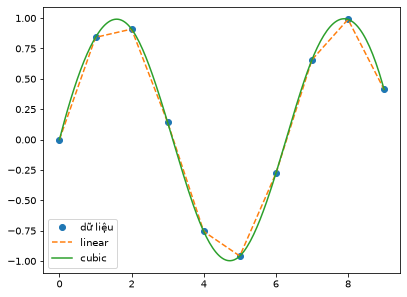

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

x = np.arange(0, 10)
y = np.sin(x)

linear = interp1d(x, y)
cubic = interp1d(x, y, kind="cubic")
xnew = np.linspace(0, 9, 200)

plt.plot(x, y, "o", label="dữ liệu")
plt.plot(xnew, linear(xnew), "--", label="linear")
plt.plot(xnew, cubic(xnew), label="cubic")
plt.legend()
plt.show()

---

## 🧠 Ghi nhớ nhanh

> - Nội suy = tạo điểm **nằm giữa** các điểm đã biết → điền dữ liệu thiếu (imputation), làm mượt.
> - `interp1d(xs, ys)` · `UnivariateSpline(xs, ys)` · `Rbf(xs, ys)` → đều trả về **hàm** để gọi với `x` mới.
> - ⚠️ `interp1d` chỉ nội suy **trong khoảng** dữ liệu gốc.

---

## 📝 Exercise — Bài tập nhanh

**❓ Câu hỏi:** Nội suy (interpolation) dùng để làm gì?

- **A.** Mã hoá dữ liệu
- **B.** Sắp xếp dữ liệu
- **C.** Tạo các điểm nằm giữa các điểm đã cho
- **D.** Xoá dữ liệu trùng lặp

<details>
<summary>👉 Xem đáp án</summary>

✅ **Đáp án: C** — Tạo các điểm nằm giữa các điểm đã cho

</details>

---

[« SciPy Matlab Arrays](009_scipy_matlab_arrays.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../../README.md) &nbsp;•&nbsp; [SciPy Statistical Significance Tests »](011_scipy_significance_tests.ipynb)